In [1]:
# CELL 1: Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from utils import visual_compare

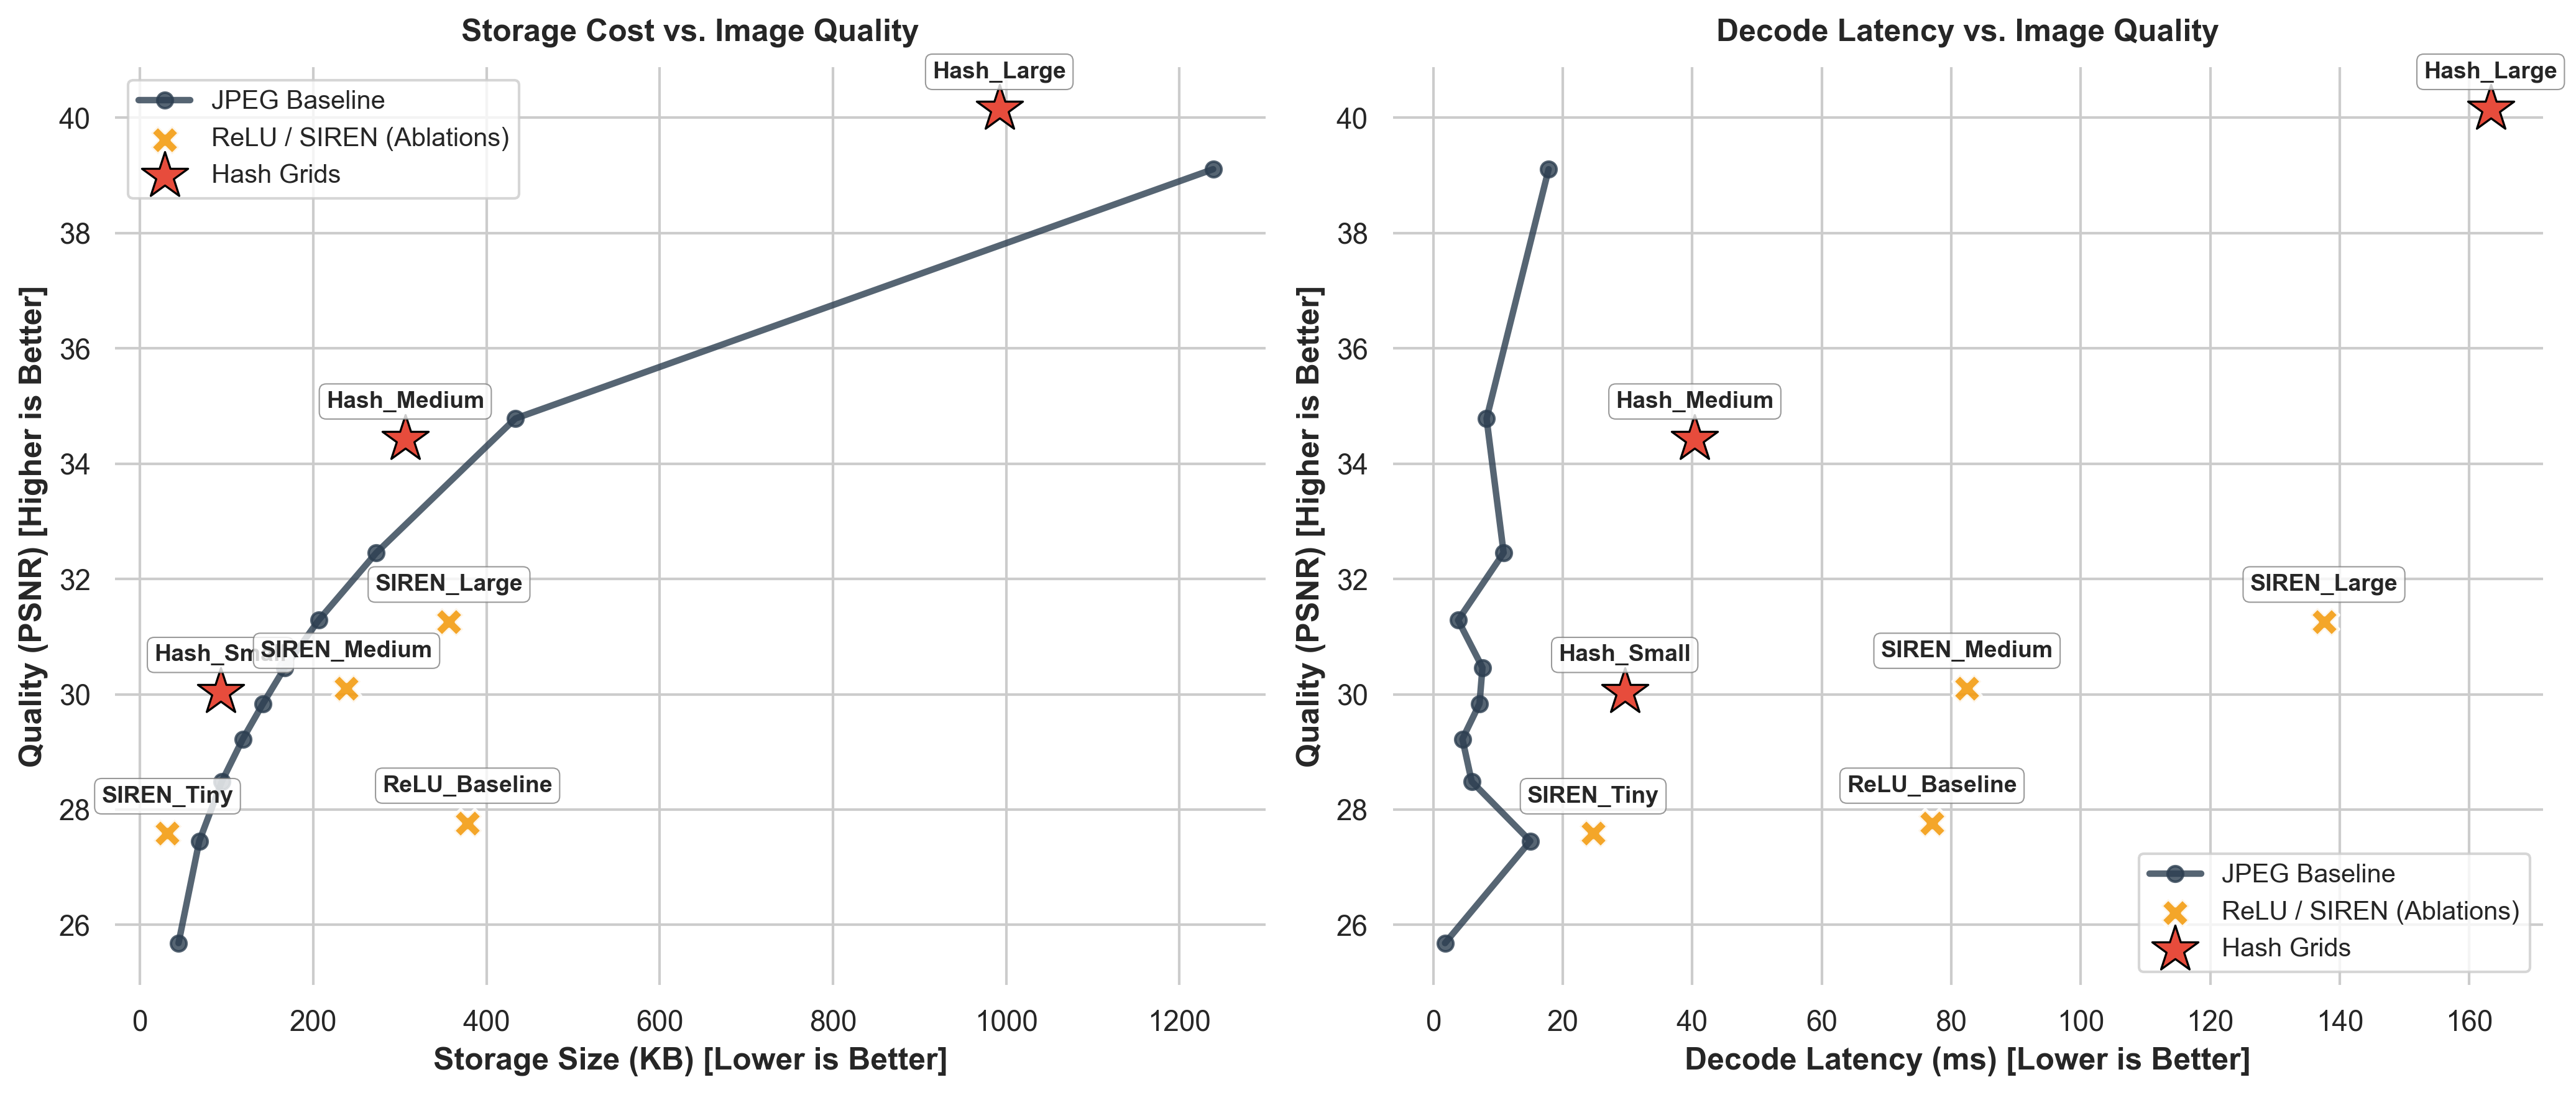

In [ ]:
# CELL 2: Beautiful 1x2 Pareto Curve Generator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the separated CSVs
df_jpeg = pd.read_csv("results/jpeg_metrics.csv")
df_hash = pd.read_csv("results/Hash_metrics.csv")
df_ablations = pd.read_csv("results/RELUandSIREN_metrics.csv")

df_neural = pd.concat([df_hash, df_ablations], ignore_index=True)

# 2. Set beautiful global aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 11, 'font.family': 'sans-serif'})

# Create a 1x2 subplot figure (perfect for a 2-page report)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=300)

def plot_on_axis(ax, x_metric, y_metric, x_label, y_label, title):
    # Plot JPEG
    ax.plot(df_jpeg[x_metric], df_jpeg[y_metric], 
            color='#2c3e50', marker='o', linestyle='-', linewidth=2.5, markersize=6,
            label='JPEG Baseline', zorder=2, alpha=0.8)
    
    # Plot Ablations
    if not df_ablations.empty:
        ax.scatter(df_ablations[x_metric], df_ablations[y_metric], 
                   color='#f39c12', marker='X', s=120, edgecolor='white', linewidth=1.2,
                   label='ReLU / SIREN (Ablations)', zorder=3, alpha=0.9)
        
    # Plot Hash Grids
    if not df_hash.empty:
        ax.scatter(df_hash[x_metric], df_hash[y_metric], 
                   color='#e74c3c', marker='*', s=350, edgecolor='black', linewidth=0.8,
                   label='Hash Grids', zorder=4)

    # Add text labels
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.5, alpha=0.8)
    for _, row in df_neural.iterrows():
        ax.annotate(row["Method"], (row[x_metric], row[y_metric]), 
                    textcoords="offset points", xytext=(0, 12), ha='center',
                    bbox=bbox_props, fontsize=9, fontweight='bold', zorder=5)

    ax.set_xlabel(x_label, fontweight='bold')
    ax.set_ylabel(y_label, fontweight='bold')
    ax.set_title(title, pad=10, fontweight='bold')
    ax.legend(loc='best', frameon=True, fontsize=10)

# --- Subplot 1: Size vs PSNR ---
plot_on_axis(ax1, x_metric="Size_KB", y_metric="PSNR", 
             x_label="Storage Size (KB) [Lower is Better]", 
             y_label="Quality (PSNR) [Higher is Better]", 
             title="Storage Cost vs. Image Quality")

# --- Subplot 2: Size vs SSIM ---
plot_on_axis(ax2, x_metric="Latency_ms", y_metric="PSNR", 
             x_label="Decode Latency (ms) [Lower is Better]", 
             y_label="Quality (PSNR) [Higher is Better]", 
             title="Decode Latency vs. Image Quality")

sns.despine(left=True, bottom=True)
plt.tight_layout()

# SAVE AS PDF FOR LATEX
plt.savefig("pareto_plots.pdf", format='pdf', bbox_inches='tight')
#Image for readme
plt.savefig("pareto_plots.jpg", format='jpg')
plt.show()